<a href="https://colab.research.google.com/github/peperjet/deep-learning/blob/main/attention/attention_260502.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 바다나우 어텐션 (Neural Machine Translation by Jointly Learning to Align and Translate)

In [ ]:
! pip install torch torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn

In [ ]:
# 바다나우
class BahdanauAttention(nn.Module):
  def __init__(self, hidden_size):
    super().__init__()
    self.W1 = nn.Linear(hidden_size, hidden_size)
    self.W2 = nn.Linear(hidden_size, hidden_size)
    self.V = nn.Linear(hidden_size, 1)

  def forward(self, query, keys):
    # 각 단어마다 중요도 점수 계산
    score = self.V(torch.tanh(self.W1(query) + self.W2(keys)))
    weights = torch.softmax(score, dim=1) # 점수를 확률로
    context = (weights * keys).sum(dim=1) # 중요한 것에 집중
    return context, weights


# 테스트
attn = BahdanauAttention(hidden_size=256)
print("바다나우 어텐션 준비 완료!")

바다나우 어텐션 준비 완료!


In [ ]:
# 어텐션 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


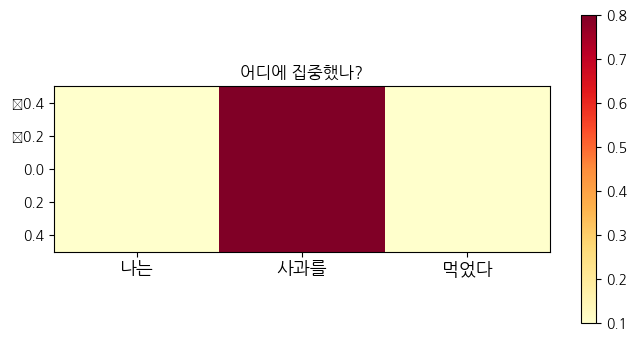

In [ ]:
# 한글 폰트 설치 및 설정
!apt-get install -y fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'

# 어텐션 가중치 시각화
def show_attention(words, weights):
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(weights, cmap='YlOrRd')
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, fontsize=13)
    plt.colorbar(im)
    plt.title("어디에 집중했나?")
    plt.show()

# 예시: "나는 사과를 먹었다" 번역할 때
words = ["나는", "사과를", "먹었다"]
# 'apple' 번역할 때 '사과를'에 가장 집중
weights = np.array([[0.1, 0.8, 0.1]])
show_attention(words, weights)

In [ ]:
# HuggingFace로 트렌스포머  써보기
!pip install transformers sentencepiece -q

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

In [ ]:
# 모델 직접 불러오기
model_name = "Helsinki-NLP/opus-mt-ko-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

# 번역
text = "나는 오늘 사과를 먹었다."
inputs = tokenizer(text, return_tensors="pt", padding=True)
translated = model.generate(**inputs)
result = tokenizer.decode(translated[0], skip_special_tokens=True)

print("원문:", text)
print("번역:", result)

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

원문: 나는 오늘 사과를 먹었다.
번역: I ate an apple today.


2. 루옹 어텐션

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class LuongAttention(nn.Module):
    def __init__(self, hidden_size, method='dot'):
        super().__init__()
        self.method = method

        # general 방식일 때만 가중치 행렬 필요
        if method == 'general':
            self.W = nn.Linear(hidden_size, hidden_size, bias=False)
        elif method == 'concat':
            self.W = nn.Linear(hidden_size * 2, hidden_size, bias=False)
            self.V = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, query, keys):
        # 방식에 따라 점수 계산
        if self.method == 'dot':
            # 가장 단순 — 그냥 내적
            score = torch.bmm(keys, query.unsqueeze(2)).squeeze(2)

        elif self.method == 'general':
            # 가중치 행렬 하나 추가
            score = torch.bmm(self.W(keys), query.unsqueeze(2)).squeeze(2)

        elif self.method == 'concat':
            # query와 keys 합쳐서 계산
            query_exp = query.unsqueeze(1).expand_as(keys)
            score = self.V(torch.tanh(self.W(torch.cat([query_exp, keys], dim=2)))).squeeze(2)

        weights = F.softmax(score, dim=1)
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)
        return context, weights


In [ ]:
# 테스트
hidden_size = 256
batch_size = 1
seq_len = 3  # "나는 사과를 먹었다" = 3개 단어

query = torch.randn(batch_size, hidden_size)
keys  = torch.randn(batch_size, seq_len, hidden_size)

# 3가지 방식 모두 테스트
for method in ['dot', 'general', 'concat']:
    attn = LuongAttention(hidden_size, method=method)
    context, weights = attn(query, keys)
    print(f"[{method}] 가중치: {weights.detach().numpy().round(3)}")

[dot] 가중치: [[0. 0. 1.]]
[general] 가중치: [[0. 1. 0.]]
[concat] 가중치: [[0.345 0.29  0.364]]


3. 스케일드 닷 프로덕트 어텐션(Attention is All you need)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.d_k = d_k  # 키 벡터 차원

    def forward(self, Q, K, V, mask=None):
        # 1. Q와 K 내적 후 스케일링
        score = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        # 2. 마스크 적용 (선택사항 — 미래 단어 못 보게 가리기)
        if mask is not None:
            score = score.masked_fill(mask == 0, -1e9)

        # 3. softmax로 확률 변환
        weights = F.softmax(score, dim=-1)

        # 4. V(값)에 가중치 적용
        output = torch.matmul(weights, V)
        return output, weights

# 테스트 — "나는 사과를 먹었다" (3단어)
d_k = 64  # 각 단어를 64차원 벡터로 표현
seq_len = 3

Q = torch.randn(1, seq_len, d_k)  # Query
K = torch.randn(1, seq_len, d_k)  # Key
V = torch.randn(1, seq_len, d_k)  # Value

attn = ScaledDotProductAttention(d_k)
output, weights = attn(Q, K, V)

print("입력 shape:", Q.shape)
print("출력 shape:", output.shape)
print("\n어텐션 가중치 (어디에 얼마나 집중?):")
w = weights[0].detach().numpy().round(3)
print(w)


입력 shape: torch.Size([1, 3, 64])
출력 shape: torch.Size([1, 3, 64])

어텐션 가중치 (어디에 얼마나 집중?):
[[0.26  0.061 0.679]
 [0.381 0.495 0.123]
 [0.409 0.271 0.319]]


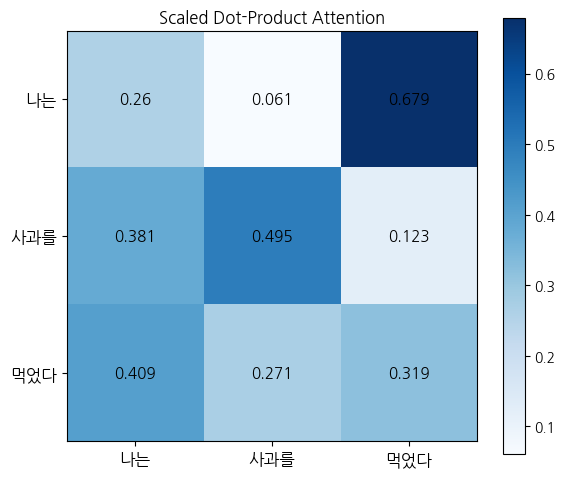

In [ ]:
# 시각화
words = ["나는", "사과를", "먹었다"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(w, cmap='Blues')
ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, fontsize=12)
ax.set_yticklabels(words, fontsize=12)
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, str(w[i][j]), ha='center', va='center', fontsize=11)
plt.colorbar(im)
plt.title("Scaled Dot-Product Attention")
plt.tight_layout()
plt.show()

In [36]:
!pip install datasets

In [37]:
from datasets import load_dataset

dataset = load_dataset("klue", "ynat")
print(dataset["train"][0])

README.md: 0.00B [00:00, ?B/s]

ynat/train-00000-of-00001.parquet:   0%|          | 0.00/4.17M [00:00<?, ?B/s]

ynat/validation-00000-of-00001.parquet:   0%|          | 0.00/847k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45678 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9107 [00:00<?, ? examples/s]

{'guid': 'ynat-v1_train_00000', 'title': '유튜브 내달 2일까지 크리에이터 지원 공간 운영', 'label': 3, 'url': 'https://news.naver.com/main/read.nhn?mode=LS2D&mid=shm&sid1=105&sid2=227&oid=001&aid=0008508947', 'date': '2016.06.30. 오전 10:36'}


In [38]:
# 문장 하나 꺼내기
text = dataset["train"][0]["title"]  # 뉴스 제목이라 짧고 좋음
print(text)

유튜브 내달 2일까지 크리에이터 지원 공간 운영


In [39]:
# 모델불러오기, attention 설정
!pip install transformers

from transformers import AutoTokenizer, AutoModel

model_name = "klue/bert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [40]:
text = "유튜브 내달 2일까지 크리에이터 지원 공간 운영"

inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

attentions = outputs.attentions

In [43]:
# 토큰 확인

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(tokens)

['[CLS]', '유튜브', '내달', '2', '##일', '##까', '##지', '크리에이터', '지원', '공간', '운영', '[SEP]']


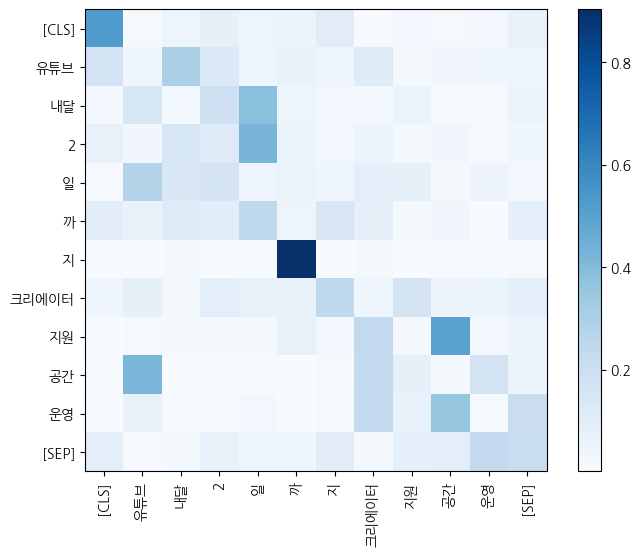

In [52]:
# 히트맵
attn = outputs.attentions[0][0][0].detach().numpy()  # 첫 번째 layer
#attn = outputs.attentions[-1][0][0].detach().numpy()  #마지막 레이어

tokens = [t.replace("##", "") for t in tokens]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(attn, cmap="Blues")

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))

ax.set_xticklabels(tokens, rotation=90)
ax.set_yticklabels(tokens)

plt.colorbar(im)
plt.show()